In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [17]:
np.random.seed(42)

number_of_students = 500

study_hours = np.random.uniform(1, 10, number_of_students)
attendance = np.random.uniform(60, 100, number_of_students)
previous_score = np.random.uniform(40, 100, number_of_students)

final_score = (
    10
    + 3.0 * study_hours
    + 0.20 * attendance
    + 0.35 * previous_score
    + np.random.normal(0, 5, number_of_students)
)

final_score = np.clip(final_score, 0, 100)

df = pd.DataFrame({
    "study_hours": study_hours,
    "attendance": attendance,
    "previous_score": previous_score,
    "final_score": final_score
})

df.head()

,study_hours,attendance,previous_score,final_score
0,4.370861,87.926469,51.107976,46.088640
1,9.556429,81.443855,72.514057,91.792690
2,7.587945,72.381105,92.376750,72.624058
3,6.387926,92.551801,83.933493,68.823868
4,2.404168,87.389247,88.393669,70.740989


## Inspect the dataset

In [18]:
df.shape
df.info()
df.describe()

df.to_csv("../data/student_scores.csv", index=False)


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   study_hours     500 non-null    float64
 1   attendance      500 non-null    float64
 2   previous_score  500 non-null    float64
 3   final_score     500 non-null    float64
dtypes: float64(4)
memory usage: 15.8 KB


## Visualize the data

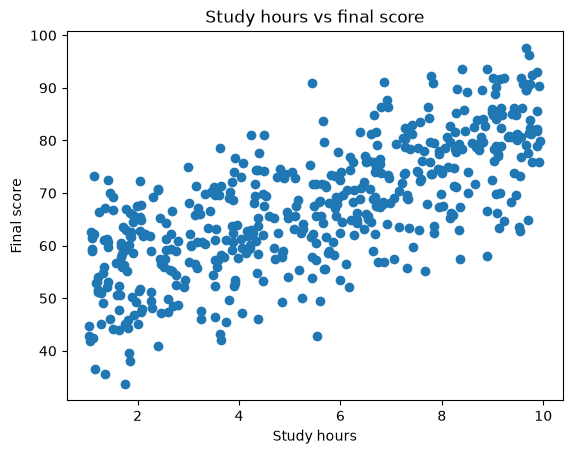

In [19]:
plt.scatter(df["study_hours"], df["final_score"])

plt.xlabel("Study hours")
plt.ylabel("Final score")
plt.title("Study hours vs final score")

plt.show()

## Split the data

In [20]:
X = df[["study_hours", "attendance", "previous_score"]]
y = df["final_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Train the model

In [21]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[3.14,0.22,0.36]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['study_hours','attendance','previous_score']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,6.558
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


## Evaluate

In [22]:
predictions = model.predict(X_test)

mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MSE: 28.451638484704333
RMSE: 5.3340077319689305
R²: 0.7778099434407537


## TEST

In [23]:
student = pd.DataFrame({
    "study_hours": [8],
    "attendance": [92],
    "previous_score": [78]
})

predicted_score = model.predict(student)[0]
predicted_score = max(0, min(100, predicted_score))

print(f"Predicted final score: {predicted_score:.2f}")

Predicted final score: 80.56


In [24]:
comparison = pd.DataFrame({
    "actual_score": y_test,
    "predicted_score": predictions
})

comparison["error"] = (
    comparison["actual_score"] - comparison["predicted_score"]
)

comparison.head(10)

,actual_score,predicted_score,error
361,67.329487,64.443612,2.885875
73,79.268051,66.610047,12.658004
374,43.986854,45.260155,-1.273300
155,55.804003,62.022513,-6.218510
104,86.209250,86.039931,0.169319
394,59.491049,60.573250,-1.082201
377,53.047394,55.400226,-2.352832
124,59.930422,63.880190,-3.949768
68,60.512598,55.545341,4.967257
450,73.768715,75.787582,-2.018866


In [25]:
comparison["absolute_error"] = comparison["error"].abs()

comparison.sort_values("absolute_error", ascending=False).head(10)

,actual_score,predicted_score,error,absolute_error
455,90.881446,75.269227,15.612219,15.612219
431,62.460993,77.841184,-15.380191,15.380191
73,79.268051,66.610047,12.658004,12.658004
0,46.088640,58.482852,-12.394213,12.394213
131,75.036954,62.713648,12.323306,12.323306
69,85.516625,74.880706,10.635919,10.635919
336,83.914112,74.316225,9.597887,9.597887
381,80.261016,71.840170,8.420846,8.420846
79,72.285588,63.926679,8.358909,8.358909
76,77.460251,69.110962,8.349289,8.349289


## relationships numerically

In [26]:
df.corr(numeric_only=True)

,study_hours,attendance,previous_score,final_score
study_hours,1.000000,0.010354,0.053966,0.720808
attendance,0.010354,1.000000,-0.025912,0.198837
previous_score,0.053966,-0.025912,1.000000,0.555064
final_score,0.720808,0.198837,0.555064,1.000000


## coefficients

In [27]:
coefficients = pd.DataFrame({"feature": X.columns, "coefficient": model.coef_})

coefficients


,feature,coefficient
0,study_hours,3.138412
1,attendance,0.223274
2,previous_score,0.363460


In [28]:
print("Intercept:", model.intercept_)

Intercept: 6.557895063328488


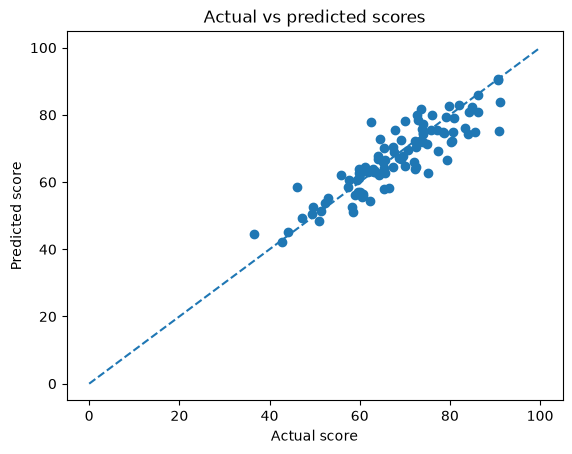

In [29]:
plt.scatter(y_test, predictions)

plt.xlabel("Actual score")
plt.ylabel("Predicted score")
plt.title("Actual vs predicted scores")

plt.plot([0, 100], [0, 100], linestyle="--")

plt.show()

In [30]:
(df["final_score"] == 100).sum()


np.int64(0)

In [31]:
(df["final_score"] < 100).sum()

np.int64(500)

In [32]:
real_df = pd.read_csv("../data/raw/student-mat.csv", sep=";")
real_df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [33]:
real_df.shape
real_df.info()
real_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [35]:
real_df.columns.tolist()

['school',
 'sex',
 'age',
 'address',
 'famsize',
 'Pstatus',
 'Medu',
 'Fedu',
 'Mjob',
 'Fjob',
 'reason',
 'guardian',
 'traveltime',
 'studytime',
 'failures',
 'schoolsup',
 'famsup',
 'paid',
 'activities',
 'nursery',
 'higher',
 'internet',
 'romantic',
 'famrel',
 'freetime',
 'goout',
 'Dalc',
 'Walc',
 'health',
 'absences',
 'G1',
 'G2',
 'G3']

In [39]:
real_df[["studytime", "absences", "failures", "G1", "G2", "G3"]].describe()

,studytime,absences,failures,G1,G2,G3
count,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
mean,87.083092,90.137548,86.576696,89.804640,89.421460,89.477099
std,133.849787,132.351367,134.172357,132.234150,132.519482,132.492931
min,0.839240,0.000000,0.000000,3.000000,0.000000,0.000000
25%,4.384968,7.472706,3.521731,7.926862,7.980649,7.946585
50%,40.495001,47.964863,40.138193,45.115752,45.022948,45.298647
75%,90.665374,94.413679,90.252681,93.155439,92.985056,93.019400
max,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000


In [40]:
real_df[["studytime", "absences", "failures", "G1", "G2", "G3"]].head(10)

,studytime,absences,failures,G1,G2,G3
count,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
mean,74.919645,79.553565,74.226365,79.061796,78.768518,78.822223
std,137.902560,135.592398,138.331631,135.436369,135.634673,135.610932
min,0.839240,0.000000,0.000000,3.000000,0.000000,0.000000
25%,1.750000,5.890823,0.125316,7.707450,7.922594,7.786340
50%,5.263291,16.376161,4.653869,12.727215,12.678481,13.103797
75%,72.990002,80.687439,72.276387,77.504289,77.367415,77.493496
max,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000


In [41]:
real_df[["studytime", "absences", "failures", "G1", "G2", "G3"]].corr()

,studytime,absences,failures,G1,G2,G3
studytime,1.000000,0.999447,0.999992,0.999750,0.999691,0.999675
absences,0.999447,1.000000,0.999386,0.999857,0.999898,0.999913
failures,0.999992,0.999386,1.000000,0.999673,0.999618,0.999603
G1,0.999750,0.999857,0.999673,1.000000,0.999970,0.999968
G2,0.999691,0.999898,0.999618,0.999970,1.000000,0.999999
G3,0.999675,0.999913,0.999603,0.999968,0.999999,1.000000
